# 03 — Frequency-Domain Analysis
**Phase 1 · Multi-fault Diagnosis of Rotating Machinery**

Goals:
- Compute FFT and Power Spectral Density (PSD) for each channel and fault condition
- Calculate bearing characteristic fault frequencies (BPFI, BPFO, BSF, FTF)
- Inspect spectral energy at fault frequencies across conditions
- Explore envelope analysis (Hilbert transform) for bearing diagnostics

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from scipy import signal
from scipy.fft import rfft, rfftfreq

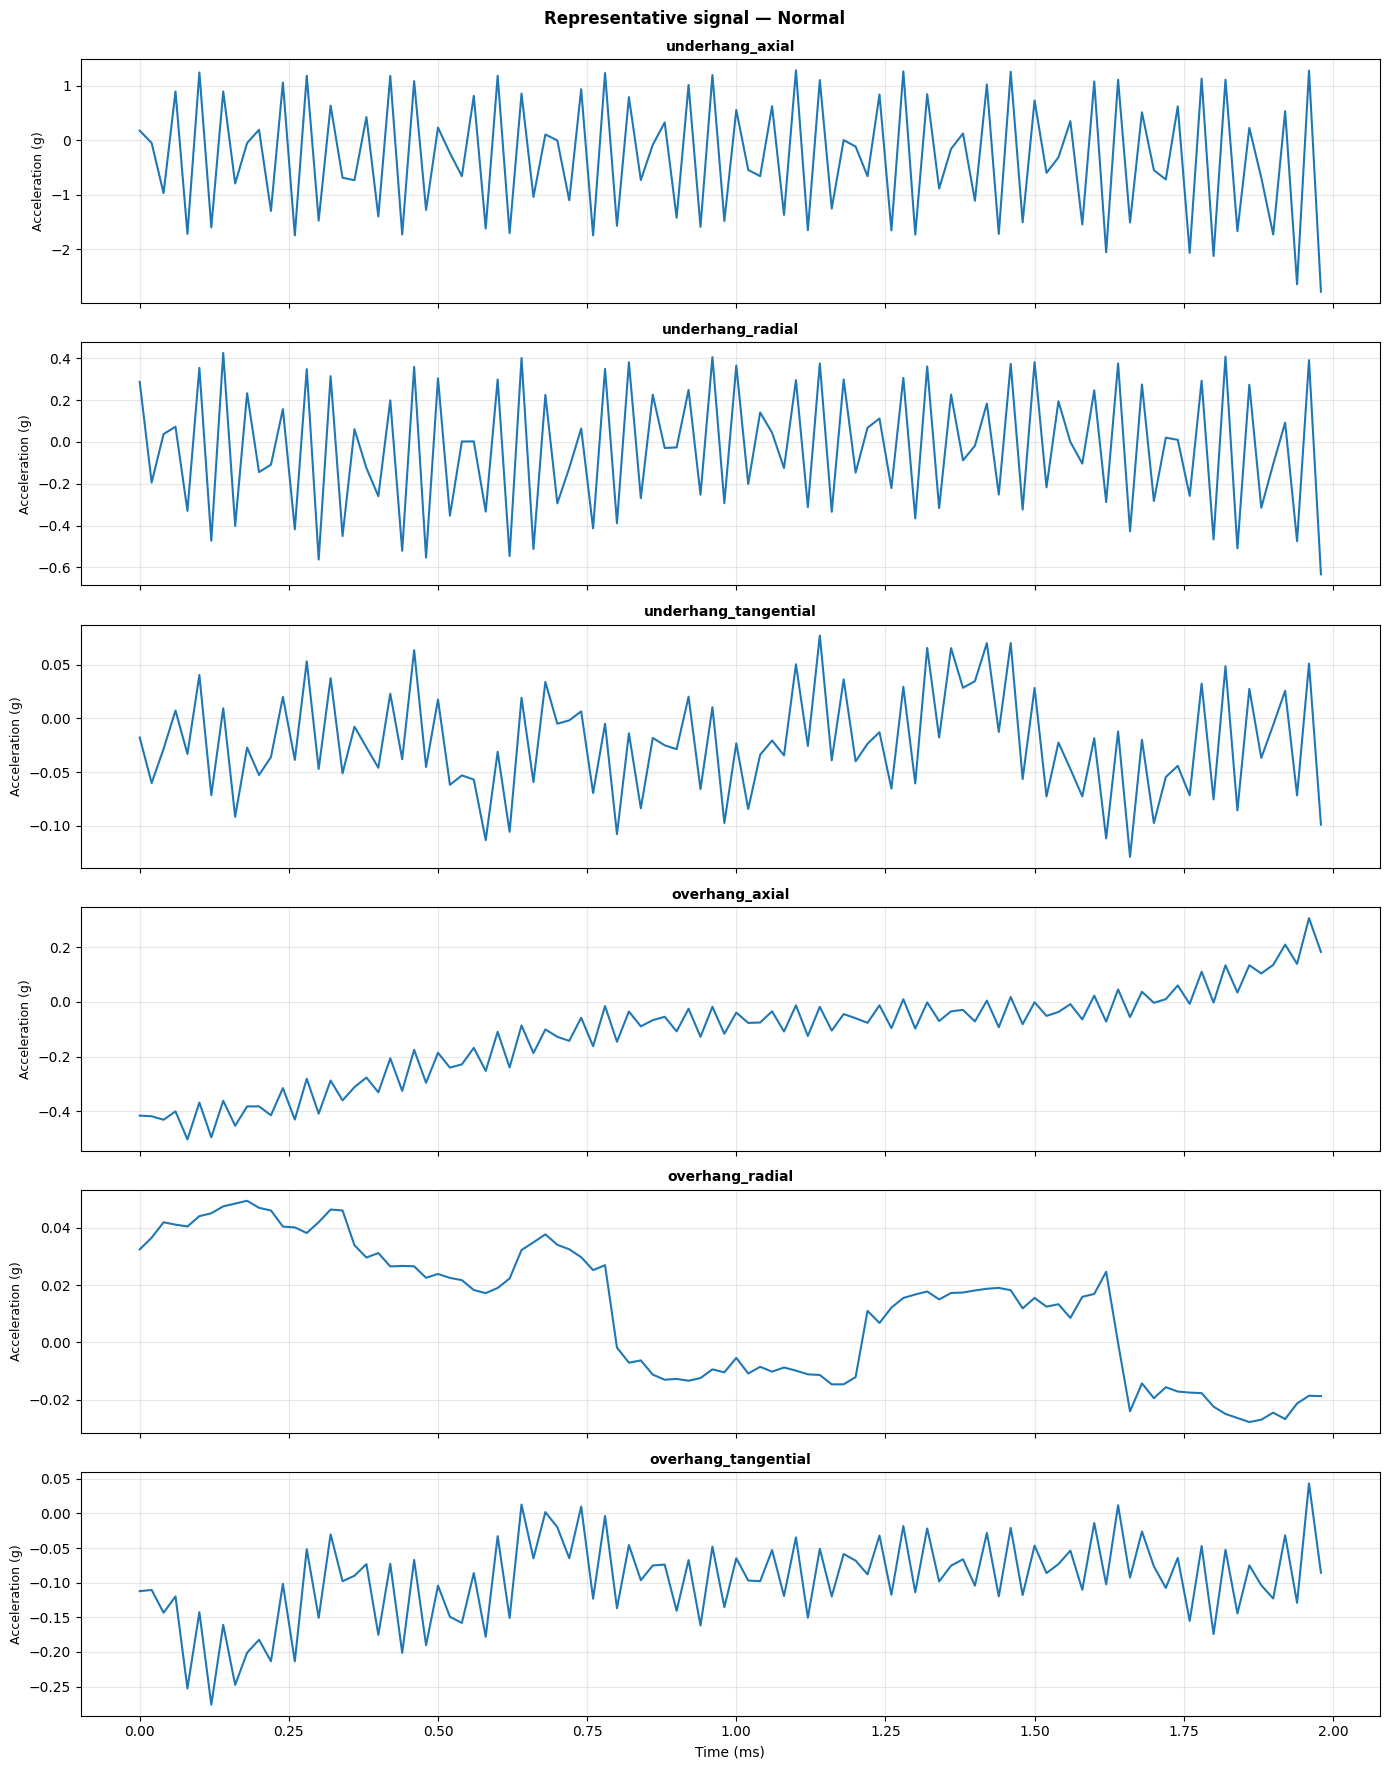

In [6]:
ACCEL_CHANNELS = [
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
]

FAULT_TYPES = metadata["fault_category"].unique()
CHANNEL     = "underhang_axial"
# CHANNEL_NAMES
N_SAMPLES   = 5_000  # first 0.1 s at 50 kHz — enough to see waveform character

fig, axes = plt.subplots(len(ACCEL_CHANNELS), 1, figsize=(14, 3 * len(ACCEL_CHANNELS)), sharex=True)

sample_path = metadata.loc[metadata["fault_category"] == "normal", "file_path"].iloc[0]
df = pd.read_csv(sample_path, header=None, names=CHANNEL_NAMES)

fs = 50_000  # Hz — MAFAULDA's sampling rate
n_samples = len(df)
time = np.arange(n_samples) / fs * 1000 # miliseconds
window_samples = int(2/1000 * fs)  # 5000    0.01 = 10 ms; 0.001 = 1 ms

for ax, accel_ch in zip(axes, ACCEL_CHANNELS):
    label    =  f"{accel_ch}"
    ax.plot(time[:window_samples], df[accel_ch].values[:window_samples])
    ax.set_ylabel("Acceleration (g)", fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (ms)")
fig.suptitle(f"Representative signal — Normal", fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

In [7]:
DATA_ROOT = Path("../../data/raw")
SAMPLING_RATE = 50_000  # Hz

CHANNEL_NAMES = [
    "tachometer",
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
    "microphone",
]

ACCEL_CHANNELS = [
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
]

BEARING = {
    "n_balls": 8,
    "ball_diameter_mm": 7.94,
    "pitch_diameter_mm": 33.50,
    "contact_angle_deg": 0.0,
}

In [8]:
def bearing_fault_frequencies(f_r: float, bearing: dict) -> dict:
    """Compute characteristic fault frequencies (Hz) given shaft rotation frequency."""
    n  = bearing["n_balls"]
    bd = bearing["ball_diameter_mm"]
    pd_ = bearing["pitch_diameter_mm"]
    ca = np.deg2rad(bearing["contact_angle_deg"])
    ratio = (bd / pd_) * np.cos(ca)
    return {
        "FTF":  f_r / 2 * (1 - ratio),
        "BPFO": n * f_r / 2 * (1 - ratio),
        "BPFI": n * f_r / 2 * (1 + ratio),
        "BSF":  (pd_ / (2 * bd)) * f_r * (1 - ratio ** 2),
    }

In [9]:
# TODO: plot FFT spectrum for each channel, overlaid per fault class

In [10]:
# TODO: mark fault frequencies on spectrum plots

In [11]:
# TODO: envelope spectrum (Hilbert) analysis for bearing fault detection

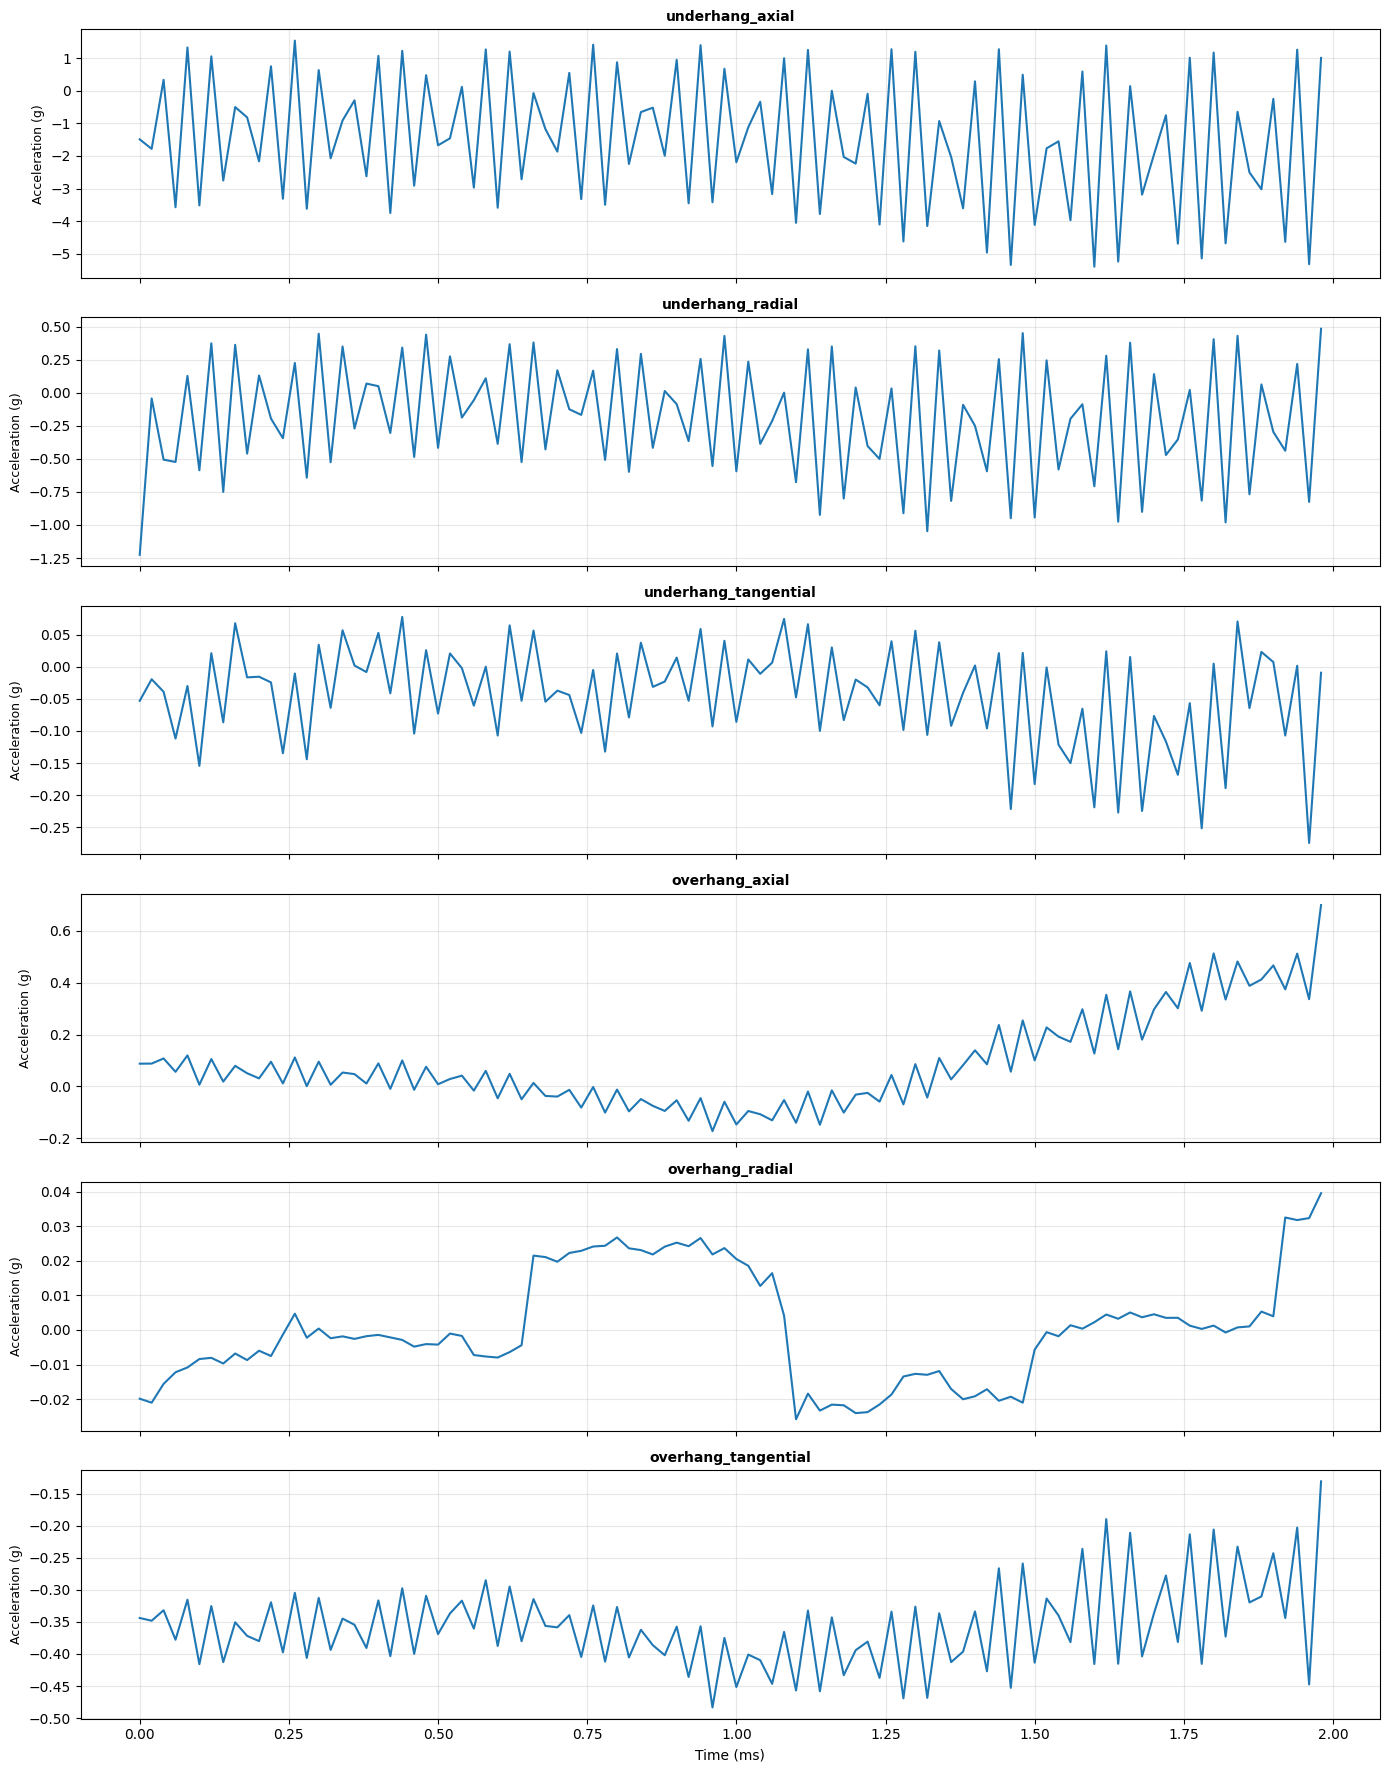

In [12]:
fig_fs, axes_fs = plt.subplots(len(ACCEL_CHANNELS), 1, figsize=(14, 3 * len(ACCEL_CHANNELS)), sharex=True)

fault_sample_path = metadata.loc[metadata["fault_category"] == "vertical-misalignment", "file_path"].iloc[0]
df_fs = pd.read_csv(fault_sample_path, header=None, names=CHANNEL_NAMES)

for ax, accel_ch in zip(axes_fs, ACCEL_CHANNELS):
    label    =  f"{accel_ch}"
    ax.plot(time[:window_samples], df_fs[accel_ch].values[:window_samples])
    ax.set_ylabel("Acceleration (g)", fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3)

axes_fs[-1].set_xlabel("Time (ms)")
fig.suptitle(f"Representative signal — Normal", fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

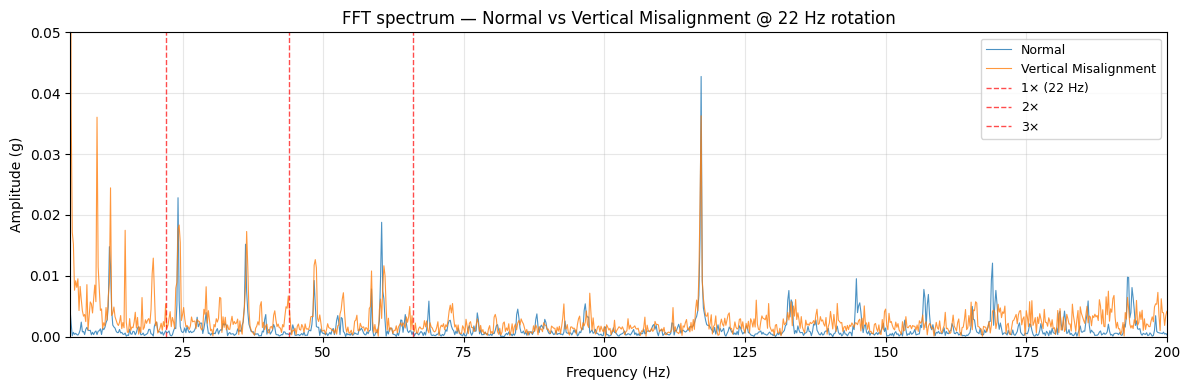

In [16]:
TARGET_FREQ = 22

def compute_fft(signal, fs):
    n = len(signal)
    fft_vals = np.abs(np.fft.rfft(signal)) * 2 / n  # two-sided to one-sided, amplitude in g
    freqs    = np.fft.rfftfreq(n, d=1/fs)
    return freqs, fft_vals

# Use the full signal (all 250,000 samples) for better frequency resolution
channel  = "underhang_radial"
rotation = TARGET_FREQ  # 22 Hz — the 1x peak we expect to see

freqs_normal,   fft_normal   = compute_fft(df[channel].values,    fs)
freqs_imbalance, fft_imbalance = compute_fft(df_fs[channel].values, fs)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(freqs_normal,    fft_normal,    label="Normal",               alpha=0.8, linewidth=0.8)
ax.plot(freqs_imbalance, fft_imbalance, label="Vertical Misalignment", alpha=0.8, linewidth=0.8)

# Mark the expected 1x, 2x, 3x rotation frequency harmonics
for harmonic in [1, 2, 3]:
    ax.axvline(harmonic * rotation, color="red", linestyle="--",
               linewidth=1, alpha=0.7, label=f"{harmonic}× ({harmonic * rotation} Hz)" if harmonic == 1 else f"{harmonic}×")

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude (g)")
ax.set_title(f"FFT spectrum — Normal vs Vertical Misalignment @ {TARGET_FREQ} Hz rotation")
# ax.set_xlim(0, 500)   # zoom into 0–500 Hz where rotation harmonics live
ax.set_xlim(5, 200)
ax.set_ylim(0, 0.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Check the actual rotation frequency of each file
print(metadata.loc[metadata["fault_category"] == "normal", ["file_path", "frequency_hz"]].iloc[0])
print(metadata.loc[metadata["fault_category"] == "vertical-misalignment", ["file_path", "frequency_hz"]].iloc[0])

file_path       /kaggle/input/datasets/vuxuancu/mafaulda-full/...
frequency_hz                                                   12
Name: 530, dtype: object
file_path       /kaggle/input/datasets/vuxuancu/mafaulda-full/...
frequency_hz                                                   12
Name: 1650, dtype: object
